# 🧬 Statistical Analysis: Metagenomic Gut Microbiome & Disease Biomarker Study
### Complete Statistical Pipeline: Descriptive Statistics, Hypothesis Testing, and Principal Component Analysis (PCA)

---

## 📋 Table of Contents
1. **[Environment Setup & Data Ingestion](#1.-Environment-Setup-&-Data-Ingestion)**
2. **[Section 1: Descriptive Statistics (Full Suite)](#2.-Section-1:-Descriptive-Statistics)**
   - 2.1 Central Tendency & Dispersion Matrix
   - 2.2 Frequency Distributions & Cross-Tabulations
   - 2.3 Visual Exploratory Suite (Histograms, Boxplots, Correlation Heatmap, Scatter Matrix, Categorical Distributions, Skewness/Kurtosis)
3. **[Section 2: Inferential Statistics — Hypothesis Testing](#3.-Section-2:-Inferential-Statistics-(Hypothesis-Testing))**
   - 3.1 Two-Sample Independent $t$-Test (BMI by Biological Sex + Effect Size $\text{Cohen's } d$)
   - 3.2 Battery of Targeted Two-Sample $t$-Tests
   - 3.3 One-Way ANOVA (Alpha Diversity Across Disease Stages + Effect Size $\eta^2$)
   - 3.4 Post-Hoc Analysis (Tukey's HSD) & Secondary ANOVA Battery
4. **[Section 3: Advanced Methods — Principal Component Analysis (PCA)](#4.-Section-3:-Advanced-Methods-(PCA))**
   - 4.1 Feature Standardization & Decomposition
   - 4.2 Scree Plot & Cumulative Explained Variance
   - 4.3 2D Biplot with Feature Loading Vectors
   - 4.4 Component Loadings Matrix & Feature Impact Heatmap
   - 4.5 3D Dimensional Projection
5. **[Executive Summary & Key Findings](#5.-Executive-Summary-&-Key-Findings)**

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")

# Configure Plot Aesthetics
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#e0e0e0",
    "axes.grid": True,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--",
    "grid.alpha": 0.8,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

PALETTE = sns.color_palette("Set2")
sns.set_palette(PALETTE)

# Output directories for saving reports/tables and figures
OUTPUT_DIR = os.path.join(os.getcwd(), "stats_output")
STAT_VIZ_DIR = os.path.join(os.getcwd(), "visualizations", "02_Statistical_Analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(STAT_VIZ_DIR, exist_ok=True)

print("[INFO] Setup complete. Output directories ready:")
print(" - Stats Output Directory :", OUTPUT_DIR)
print(" - Visualizations Directory:", STAT_VIZ_DIR)

[INFO] Setup complete. Output directories ready:
 - Stats Output Directory : d:\MITACS PROJECTS\Project2_Microbiome_Analysis\stats_output
 - Visualizations Directory: d:\MITACS PROJECTS\Project2_Microbiome_Analysis\visualizations\02_Statistical_Analysis


In [2]:
# Load Cleaned Dataset
meta = pd.read_csv("dataset/curated_sample_metadata.csv")
genus = pd.read_csv("dataset/curated_genus_relative_abundance.csv.gz")

# Merge
df = pd.merge(meta, genus, on="Sample")

# Compute key ecological features
taxa_cols = [c for c in genus.columns if c != 'Sample']
genus_mat = df[taxa_cols].values
df['Shannon'] = stats.entropy(genus_mat, axis=1)
df['Richness'] = np.sum(genus_mat > 0, axis=1)

# Phyla extraction
phyla_map = {}
for col in taxa_cols:
    parts = col.split(';')
    p = 'Unknown'
    for part in parts:
        if part.startswith('p__'):
            p = part.replace('p__', '')
            break
    if p not in phyla_map:
        phyla_map[p] = []
    phyla_map[p].append(col)

for p, cols in phyla_map.items():
    df[f'p__{p}'] = df[cols].sum(axis=1)

firm_sum = df[['p__Firmicutes_A', 'p__Firmicutes', 'p__Firmicutes_C']].sum(axis=1) + 1e-6
df['BF_Ratio'] = (df['p__Bacteroidota'] + 1e-6) / firm_sum

print(f"Dataset Loaded Successfully:")
print(f" - Total Samples (Rows)   : {df.shape[0]:,}")
print(f" - Total Features (Cols)  : {df.shape[1]:,}")

# Feature Sets
NUMERIC_COLS = [
    "Age", "BMI", "Brinkman Index", "Alcohol",
    "Shannon", "Richness", "BF_Ratio",
    "p__Bacteroidota", "p__Firmicutes_A", "p__Proteobacteria"
]

CATEGORICAL_COLS = [
    "Gender", "Study.Group", "Stage", "Tumor location"
]

missing_summary = df[NUMERIC_COLS + CATEGORICAL_COLS].isna().sum()
print("Missing values across features:", missing_summary[missing_summary > 0].to_dict() if missing_summary.sum() > 0 else "0 missing values across all features.")

Dataset Loaded Successfully:
 - Total Samples (Rows)   : 347
 - Total Features (Cols)  : 12,082
Missing values across features: 0 missing values across all features.


---
# 📊 2. Section 1: Descriptive Statistics (Full Suite)

Descriptive statistics quantitatively summarize the key properties and distributions of the dataset.

### Metrics Computed:
- **Central Tendency:** Mean ($\mu = \frac{1}{N}\sum x_i$), Median (50th percentile), Mode (most frequent observation)
- **Dispersion & Spread:** Standard Deviation ($\sigma = \sqrt{\frac{\sum (x_i - \bar{x})^2}{N-1}}$), Variance ($\sigma^2$), Range ($\max - \min$), Interquartile Range ($\text{IQR} = Q_3 - Q_1$)
- **Distributional Shape:**
  - **Skewness ($g_1$):** Measures asymmetry around the mean.
    - $g_1 = 0$: Symmetric distribution
    - $g_1 > 0$: Right-skewed (positive tail)
    - $g_1 < 0$: Left-skewed (negative tail)
  - **Kurtosis ($g_2$):** Measures tail heaviness relative to a normal distribution (Excess Kurtosis, where Normal = 0).
    - $g_2 > 0$: Leptokurtic (heavy tails, frequent outliers)
    - $g_2 < 0$: Platykurtic (light tails, fewer outliers)

In [3]:
# 2.1 Central Tendency and Dispersion Matrix
desc_metrics = []

for col in NUMERIC_COLS:
    s = df[col].dropna()
    mode_val = s.mode().iloc[0] if not s.mode().empty else np.nan
    q25, q75 = np.percentile(s, [25, 75])
    iqr_val = q75 - q25
    skew_val = stats.skew(s, bias=False)
    kurt_val = stats.kurtosis(s, bias=False)  # excess kurtosis
    
    desc_metrics.append({
        "Feature": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": mode_val,
        "Std_Dev": s.std(),
        "Variance": s.var(),
        "IQR": iqr_val,
        "Range": s.max() - s.min(),
        "Min": s.min(),
        "Max": s.max(),
        "Skewness": skew_val,
        "Kurtosis": kurt_val
    })

desc_df = pd.DataFrame(desc_metrics).set_index("Feature")
display(desc_df.round(3))

# Export to CSV
desc_df.to_csv(os.path.join(OUTPUT_DIR, "descriptive_summary.csv"))
print("[INFO] Saved descriptive statistics to stats_output/descriptive_summary.csv")

,Mean,Median,Mode,Std_Dev,Variance,IQR,Range,Min,Max,Skewness,Kurtosis
Feature,,,,,,,,,,,
Age,63.239,65.000,69.000,10.278,105.633,14.000,51.000,28.000,79.000,-0.801,0.130
BMI,23.016,22.680,23.665,3.193,10.193,3.845,21.409,16.142,37.551,1.056,2.555
Brinkman Index,401.931,216.000,0.000,526.357,277051.799,640.000,3200.000,0.000,3200.000,1.845,4.253
Alcohol,248.244,44.200,0.000,380.044,144433.638,360.000,1953.000,0.000,1953.000,1.994,4.206
Shannon,2.976,3.008,1.316,0.556,0.309,0.761,2.929,1.316,4.245,-0.226,-0.010
Richness,2799.677,2714.000,2220.000,729.764,532555.381,796.500,4966.000,1051.000,6017.000,1.032,2.359
BF_Ratio,1.746,1.439,0.018,1.249,1.560,1.391,9.260,0.018,9.278,1.913,5.699
p__Bacteroidota,0.524,0.535,0.016,0.158,0.025,0.224,0.838,0.016,0.854,-0.417,-0.005
p__Firmicutes_A,0.326,0.314,0.037,0.141,0.020,0.208,0.740,0.037,0.777,0.299,-0.415


[INFO] Saved descriptive statistics to stats_output/descriptive_summary.csv


### 2.2 Categorical Distributions & Cross-Tabulations

In [4]:
# Categorical Frequency Breakdown
cat_tables = {}

for col in CATEGORICAL_COLS:
    freq = df[col].value_counts(dropna=False)
    prop = df[col].value_counts(normalize=True, dropna=False) * 100
    tab = pd.DataFrame({"Frequency": freq, "Proportion (%)": prop.round(2)})
    cat_tables[col] = tab
    print(f"\n--- {col.upper()} ---")
    display(tab)

# Cross-tabulation: Gender x Study.Group
print("\n--- CROSS-TABULATION: Gender x Study Group ---")
ct = pd.crosstab(df["Gender"], df["Study.Group"], margins=True)
display(ct)

# Export frequency summaries
with open(os.path.join(OUTPUT_DIR, "frequency_tables.csv"), "w") as f:
    for name, tab in cat_tables.items():
        f.write(f"Feature: {name}\n")
        tab.to_csv(f)
        f.write("\n")
    f.write("Cross-Tabulation: Gender x Study.Group\n")
    ct.to_csv(f)
print("[INFO] Saved categorical summaries to stats_output/frequency_tables.csv")


--- GENDER ---


,Frequency,Proportion (%)
Gender,,
Male,204,58.79
Female,143,41.21



--- STUDY.GROUP ---


,Frequency,Proportion (%)
Study.Group,,
Healthy,127,36.60
Stage_I_II,69,19.88
Stage_III_IV,54,15.56
MP,40,11.53
HS,30,8.65
Stage_0,27,7.78



--- STAGE ---


...


--- TUMOR LOCATION ---


,Frequency,Proportion (%)
Tumor location,,
-,197,56.77
Rectum,69,19.88
Right colon,44,12.68
Left colon,32,9.22
Left colon and Right colon,3,0.86
Rectum and Left colon,1,0.29
"Rectum, Left colon and Right colon",1,0.29



--- CROSS-TABULATION: Gender x Study Group ---


Study.Group,HS,Healthy,MP,Stage_0,Stage_III_IV,Stage_I_II,All
Gender,,,,,,,
Female,17,56,9,14,24,23,143
Male,13,71,31,13,30,46,204
All,30,127,40,27,54,69,347


[INFO] Saved categorical summaries to stats_output/frequency_tables.csv


### 2.3 Descriptive Visualization Suite

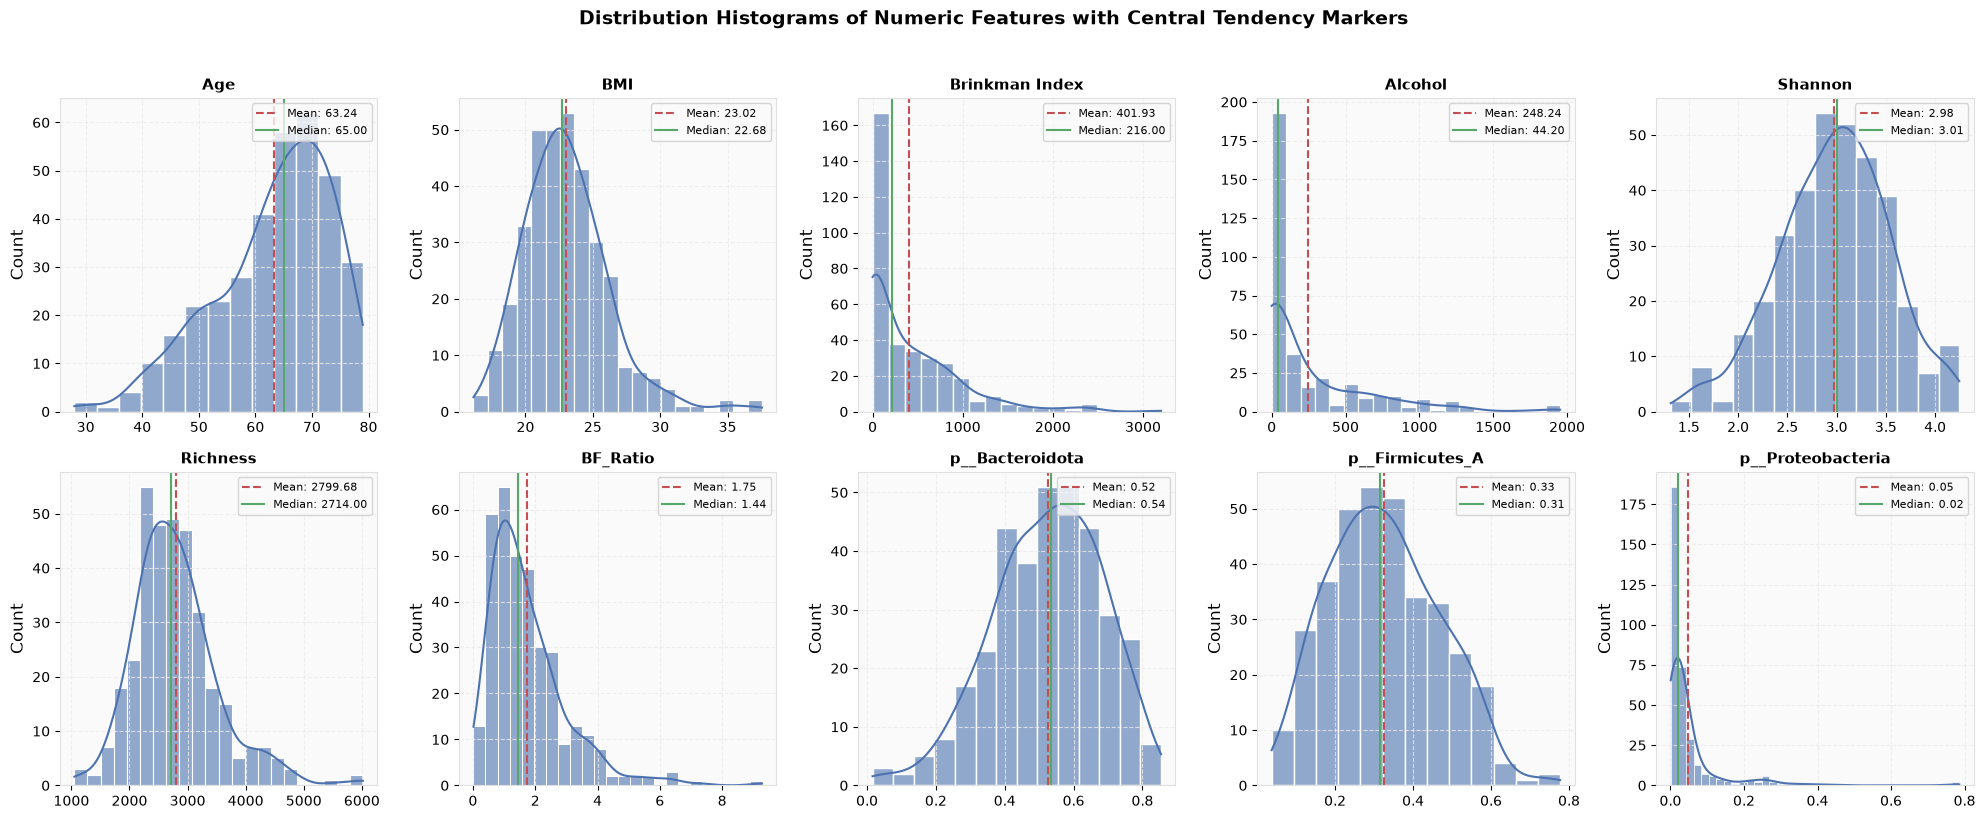

In [5]:
# 1. Feature Distribution Histograms with Mean & Median Markers
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    data = df[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    sns.histplot(data, kde=True, ax=ax, color="#4c72b0", edgecolor="white", alpha=0.6)
    ax.axvline(mean_val, color="#c44e52", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="#55a868", linestyle="-", linewidth=1.5, label=f"Median: {median_val:.2f}")
    
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.legend(loc="upper right", frameon=True, fontsize=8)

plt.suptitle("Distribution Histograms of Numeric Features with Central Tendency Markers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_histograms.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "01_histograms.png"), dpi=150, bbox_inches="tight")
plt.show()

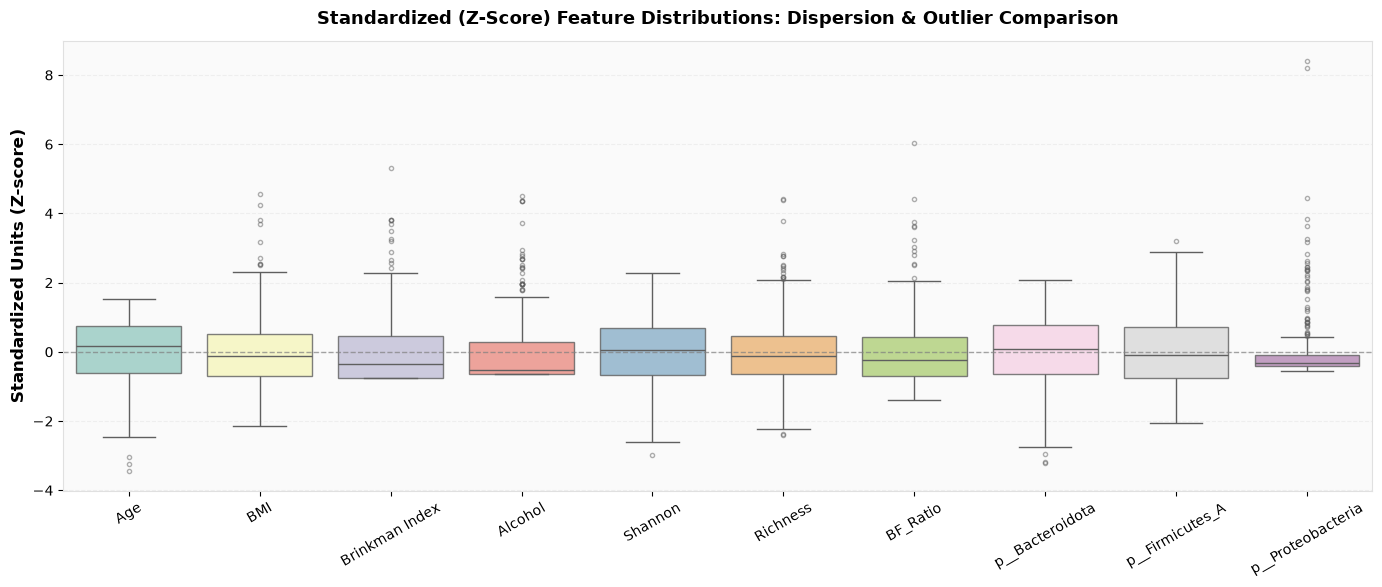

In [6]:
# 2. Standardized Boxplots across Numeric Features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[NUMERIC_COLS].dropna()), columns=NUMERIC_COLS)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_scaled, palette="Set3", ax=ax, boxprops=dict(alpha=0.8), flierprops=dict(marker="o", markersize=3, alpha=0.5))
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Standardized (Z-Score) Feature Distributions: Dispersion & Outlier Comparison", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Standardized Units (Z-score)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_boxplots.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "02_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

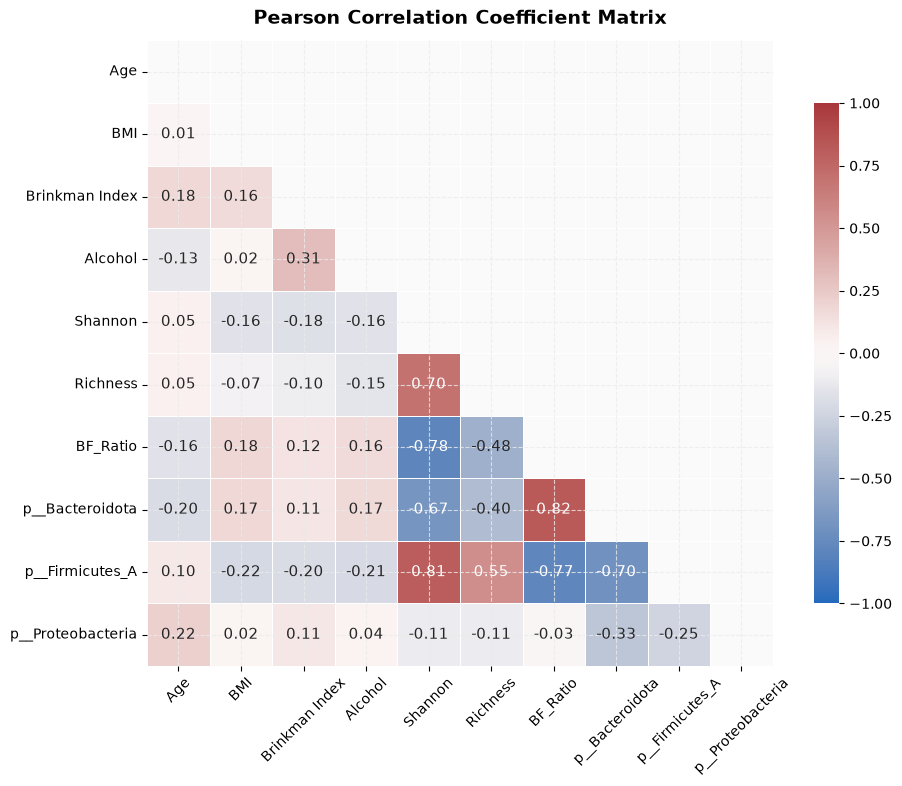

In [7]:
# 3. Pearson Correlation Heatmap
corr_mat = df[NUMERIC_COLS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation Coefficient Matrix", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "03_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "03_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

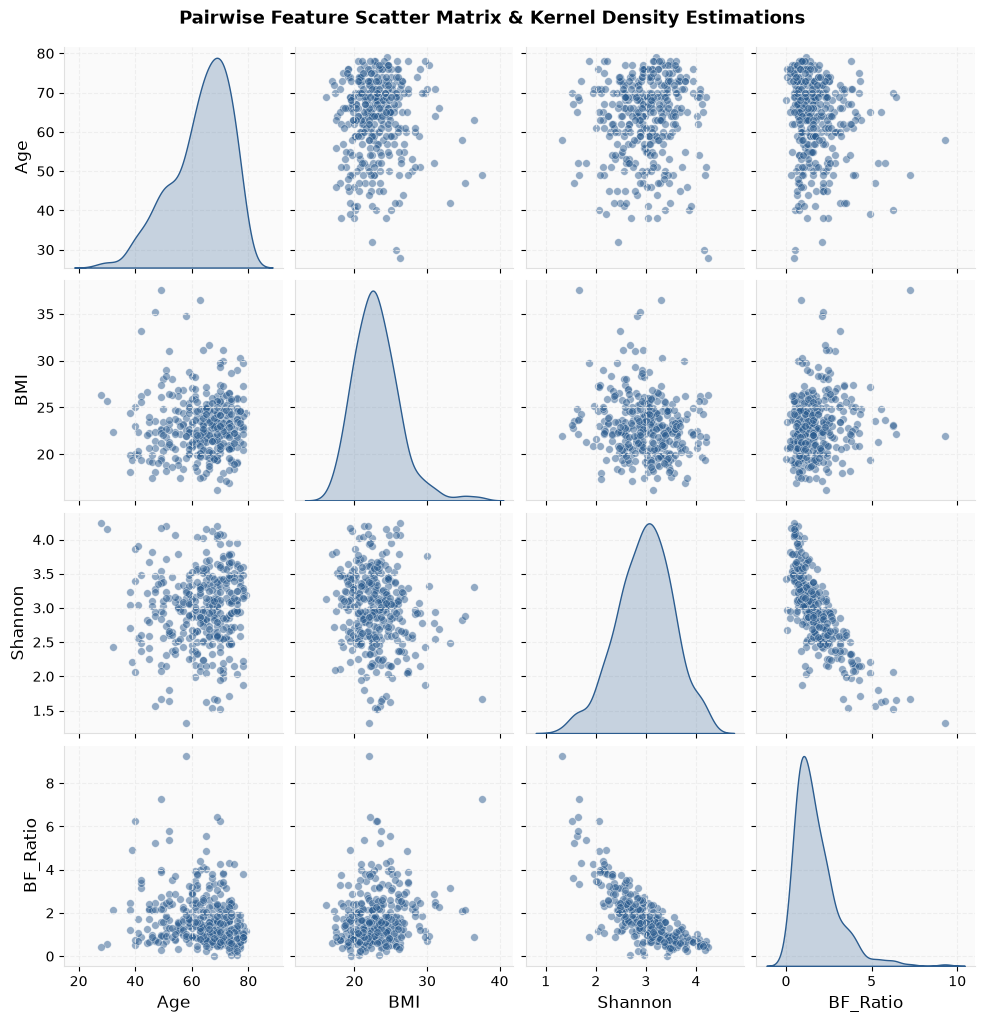

In [8]:
# 4. Pairwise Scatter Matrix
core_scatter_cols = ["Age", "BMI", "Shannon", "BF_Ratio"]
g = sns.pairplot(df[core_scatter_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.5, "s": 30, "color": "#2b5c8f"},
                 diag_kws={"color": "#2b5c8f", "fill": True})
g.fig.suptitle("Pairwise Feature Scatter Matrix & Kernel Density Estimations", fontsize=13, fontweight="bold", y=1.02)

g.savefig(os.path.join(OUTPUT_DIR, "04_scatter_matrix.png"), dpi=150, bbox_inches="tight")
g.savefig(os.path.join(STAT_VIZ_DIR, "04_scatter_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

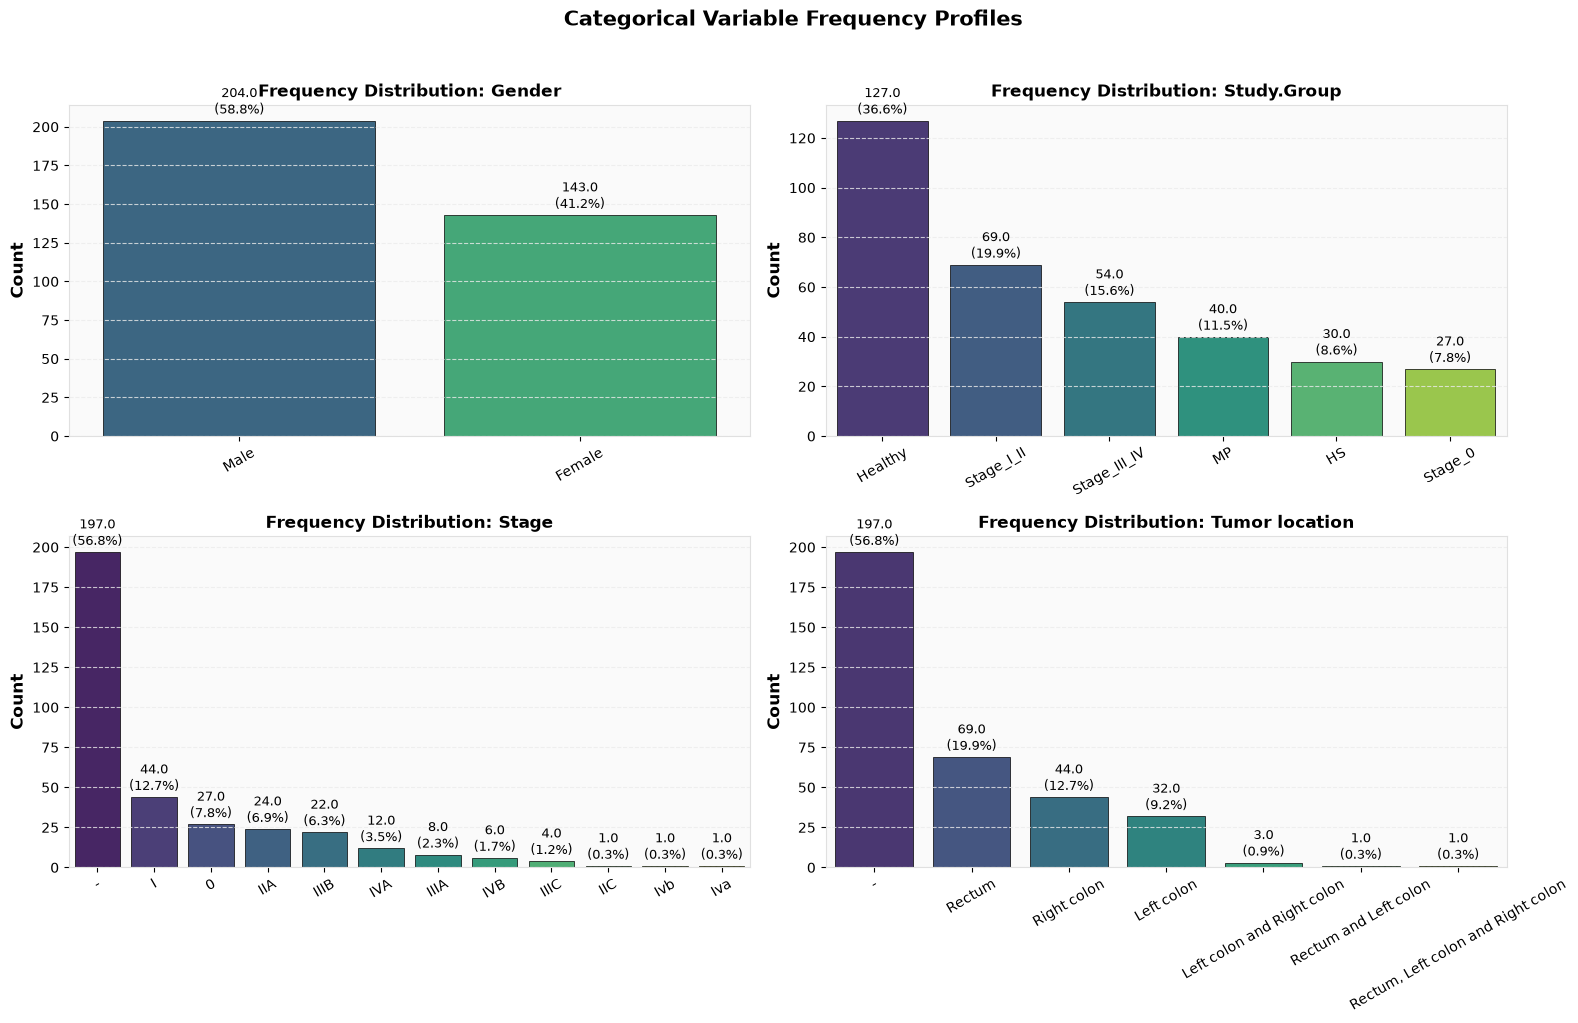

In [9]:
# 5. Categorical Features Distribution Breakdown
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="viridis", ax=ax, edgecolor="black", linewidth=0.5)
    ax.set_title(f"Frequency Distribution: {col}", fontweight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    
    # Label count and percentage
    total = len(df[col].dropna())
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{height}\n({height/total*100:.1f}%)",
                    (p.get_x() + p.get_width() / 2., height),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 2),
                    textcoords="offset points")

plt.suptitle("Categorical Variable Frequency Profiles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "05_categorical_bars.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "05_categorical_bars.png"), dpi=150, bbox_inches="tight")
plt.show()

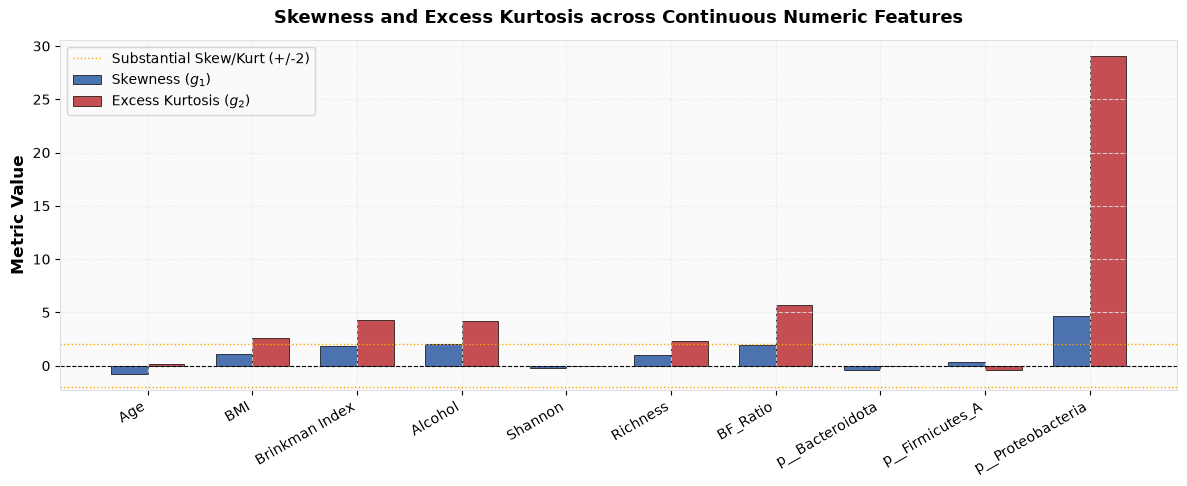

In [10]:
# 6. Distributional Shape: Skewness & Kurtosis Evaluation
shape_df = desc_df[["Skewness", "Kurtosis"]].copy()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(shape_df))
width = 0.35

rects1 = ax.bar(x - width/2, shape_df["Skewness"], width, label="Skewness ($g_1$)", color="#4c72b0", edgecolor="black", linewidth=0.5)
rects2 = ax.bar(x + width/2, shape_df["Kurtosis"], width, label="Excess Kurtosis ($g_2$)", color="#c44e52", edgecolor="black", linewidth=0.5)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.axhline(2, color="orange", linestyle=":", linewidth=1, label="Substantial Skew/Kurt (+/-2)")
ax.axhline(-2, color="orange", linestyle=":", linewidth=1)

ax.set_title("Skewness and Excess Kurtosis across Continuous Numeric Features", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(shape_df.index, rotation=30, ha="right")
ax.set_ylabel("Metric Value", fontweight="bold")
ax.legend(frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "06_skew_kurtosis.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "06_skew_kurtosis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# 🔬 3. Section 2: Inferential Statistics (Hypothesis Testing)

We execute parametric and non-parametric hypothesis testing suites to assess physiological differences across biological sex, health status, and disease stages.

### Tests Applied:
1. **Independent Two-Sample $t$-Test:** Evaluates equality of means between two independent groups.
   - **Effect Size:** **Cohen's $d$**:
     $$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}, \quad s_{\text{pooled}} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$
2. **One-Way Analysis of Variance (ANOVA):** Tests equality of population means across $\ge 3$ groups.
   - **Effect Size:** **Eta-Squared ($\eta^2$):**
     $$\eta^2 = \frac{SS_{\text{between}}}{SS_{\text{total}}}$$
3. **Post-Hoc Analysis:** **Tukey's Honestly Significant Difference (HSD)** test controlling the family-wise error rate.

=== Primary Independent Samples t-Test: BMI by Sex ===
Male   : N = 204, Mean = 23.68, Std = 2.91
Female : N = 143, Mean = 22.07, Std = 3.34
Levene Test p-value: 0.1937 (Equal variance assumed: True)
t-statistic: 4.7434, p-value: 3.0809e-06
Cohen's d  : 0.5173 (medium)


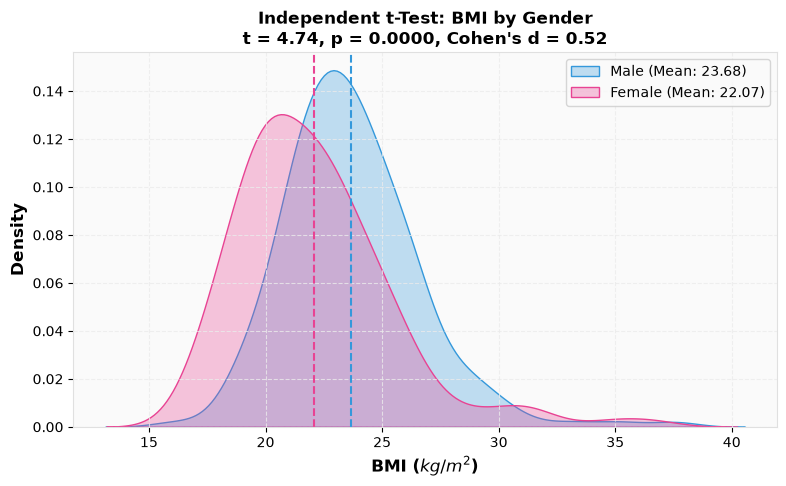

In [11]:
# 3.1 Primary Independent Samples t-Test: BMI by Biological Sex
group_male = df[df["Gender"] == "Male"]["BMI"].dropna()
group_female = df[df["Gender"] == "Female"]["BMI"].dropna()

# Check normality and equal variance
shapiro_m = stats.shapiro(group_male)
shapiro_f = stats.shapiro(group_female)
levene_test = stats.levene(group_male, group_female)

# Independent t-test (Welch's if unequal variance)
equal_var = levene_test.pvalue > 0.05
t_stat, p_val = stats.ttest_ind(group_male, group_female, equal_var=equal_var)

# Cohen's d
n1, n2 = len(group_male), len(group_female)
s1, s2 = group_male.std(), group_female.std()
s_pooled = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))
cohens_d = (group_male.mean() - group_female.mean()) / s_pooled

print("=== Primary Independent Samples t-Test: BMI by Sex ===")
print(f"Male   : N = {n1}, Mean = {group_male.mean():.2f}, Std = {s1:.2f}")
print(f"Female : N = {n2}, Mean = {group_female.mean():.2f}, Std = {s2:.2f}")
print(f"Levene Test p-value: {levene_test.pvalue:.4f} (Equal variance assumed: {equal_var})")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
print(f"Cohen's d  : {cohens_d:.4f} ({'negligible' if abs(cohens_d) < 0.2 else 'small' if abs(cohens_d) < 0.5 else 'medium'})")

# Export
ttest_res = pd.DataFrame([{
    "Test": "BMI by Gender (Male vs Female)",
    "t_statistic": t_stat,
    "p_value": p_val,
    "Cohens_d": cohens_d,
    "Male_Mean": group_male.mean(),
    "Female_Mean": group_female.mean()
}])
ttest_res.to_csv(os.path.join(OUTPUT_DIR, "ttest_results.csv"), index=False)

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(group_male, color="#3498db", fill=True, alpha=0.3, label=f"Male (Mean: {group_male.mean():.2f})", ax=ax)
sns.kdeplot(group_female, color="#e84393", fill=True, alpha=0.3, label=f"Female (Mean: {group_female.mean():.2f})", ax=ax)
ax.axvline(group_male.mean(), color="#3498db", linestyle="--", linewidth=1.5)
ax.axvline(group_female.mean(), color="#e84393", linestyle="--", linewidth=1.5)

ax.set_title(f"Independent t-Test: BMI by Gender\nt = {t_stat:.2f}, p = {p_val:.4f}, Cohen's d = {cohens_d:.2f}", fontsize=12, fontweight="bold")
ax.set_xlabel("BMI ($kg/m^2$)", fontweight="bold")
ax.set_ylabel("Density", fontweight="bold")
ax.legend(frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "07_ttest_bmi_sex.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "07_ttest_bmi_sex.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# 3.2 Battery of Targeted Two-Sample t-Tests: Healthy vs CRC Cohorts
crc_mask = df["Study.Group"].isin(["Stage_0", "Stage_I_II", "Stage_III_IV"])
healthy_mask = df["Study.Group"] == "Healthy"

battery_results = []
battery_features = ["Age", "BMI", "Shannon", "Richness", "BF_Ratio", "p__Bacteroidota", "p__Firmicutes_A"]

for col in battery_features:
    g_crc = df.loc[crc_mask, col].dropna()
    g_hea = df.loc[healthy_mask, col].dropna()
    
    t_val, p_val = stats.ttest_ind(g_crc, g_hea, equal_var=False)
    mwu_val, mwu_p = stats.mannwhitneyu(g_crc, g_hea, alternative="two-sided")
    
    n_c, n_h = len(g_crc), len(g_hea)
    s_c, s_h = g_crc.std(), g_hea.std()
    s_pool = np.sqrt(((n_c - 1)*s_c**2 + (n_h - 1)*s_h**2) / (n_c + n_h - 2))
    cd = (g_crc.mean() - g_hea.mean()) / s_pool if s_pool > 0 else 0
    
    battery_results.append({
        "Feature": col,
        "Healthy_Mean": round(g_hea.mean(), 3),
        "CRC_Mean": round(g_crc.mean(), 3),
        "t_statistic": round(t_val, 3),
        "p_value": f"{p_val:.4e}" if p_val < 0.001 else f"{p_val:.4f}",
        "Mann_Whitney_p": f"{mwu_p:.4e}" if mwu_p < 0.001 else f"{mwu_p:.4f}",
        "Cohens_d": round(cd, 3)
    })

batt_df = pd.DataFrame(battery_results)
display(batt_df)
batt_df.to_csv(os.path.join(OUTPUT_DIR, "ttest_battery_results.csv"), index=False)
print("[INFO] Saved t-test battery results to stats_output/ttest_battery_results.csv")

,Feature,Healthy_Mean,CRC_Mean,t_statistic,p_value,Mann_Whitney_p,Cohens_d
0,Age,64.654,62.460,-1.761,0.0795,0.0288,-0.213
1,BMI,22.963,23.124,0.432,0.6663,0.7582,0.051
2,Shannon,2.928,3.008,1.204,0.2295,0.1840,0.143
3,Richness,2752.504,2762.853,0.122,0.9030,0.8673,0.015
4,BF_Ratio,1.645,1.815,1.158,0.2479,0.1376,0.139
5,p__Bacteroidota,0.509,0.534,1.267,0.2064,0.2618,0.155
6,p__Firmicutes_A,0.337,0.318,-1.141,0.2549,0.2937,-0.137


[INFO] Saved t-test battery results to stats_output/ttest_battery_results.csv


=== Primary One-Way ANOVA: BMI Across Disease Stages ===
F-statistic: 0.9099, p-value: 0.4746
Eta-Squared (eta^2): 0.0132 (small)

--- Tukey Honestly Significant Difference (HSD) Summary ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2    meandiff p-adj   lower  upper  reject
---------------------------------------------------------------
          HS      Healthy   0.5193 0.9673 -1.3394 2.3779  False
          HS           MP   0.7685  0.919 -1.4429 2.9799  False
          HS      Stage_0   1.6788 0.3554 -0.7501 4.1076  False
          HS Stage_III_IV    0.503 0.9828  -1.582 2.5879  False
          HS   Stage_I_II     0.43 0.9899 -1.5723 2.4324  False
     Healthy           MP   0.2493 0.9981 -1.4108 1.9094  False
     Healthy      Stage_0   1.1595 0.5244 -0.7809 3.0999  False
     Healthy Stage_III_IV  -0.0163    1.0 -1.5038 1.4711  False
     Healthy   Stage_I_II  -0.0893    1.0 -1.4586 1.2801  False
          MP      Stage_0   0.9102 0.8626

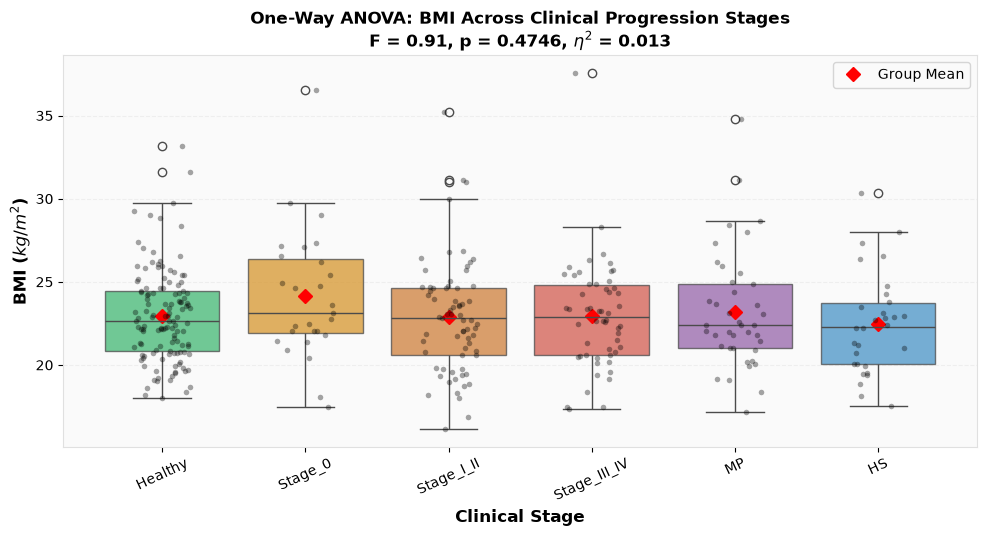

In [13]:
# 3.3 Primary One-Way ANOVA: BMI Across Disease Progression Stages
stage_order = ['Healthy', 'Stage_0', 'Stage_I_II', 'Stage_III_IV', 'MP', 'HS']
anova_groups = [df[df["Study.Group"] == s]["BMI"].dropna() for s in stage_order]

f_stat, p_val = stats.f_oneway(*anova_groups)

# Calculate Eta-Squared (eta^2 = SS_between / SS_total)
all_data = df[df["Study.Group"].isin(stage_order)]["BMI"].dropna()
grand_mean = all_data.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in anova_groups)
ss_total = sum((all_data - grand_mean)**2)
eta_sq = ss_between / ss_total

print("=== Primary One-Way ANOVA: BMI Across Disease Stages ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
print(f"Eta-Squared (eta^2): {eta_sq:.4f} ({'small' if eta_sq < 0.06 else 'medium' if eta_sq < 0.14 else 'large'})")

# Post-Hoc Tukey HSD Test
tukey = pairwise_tukeyhsd(endog=all_data, groups=df.loc[all_data.index, "Study.Group"], alpha=0.05)
print("\n--- Tukey Honestly Significant Difference (HSD) Summary ---")
print(tukey.summary())

# Export ANOVA
anova_res = pd.DataFrame([{
    "Comparison": "BMI Across 6 Disease Stages",
    "F_statistic": f_stat,
    "p_value": p_val,
    "Eta_Squared": eta_sq
}])
anova_res.to_csv(os.path.join(OUTPUT_DIR, "anova_results.csv"), index=False)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5.5))
palette = {'Healthy': '#2ecc71', 'Stage_0': '#f39c12', 'Stage_I_II': '#e67e22', 'Stage_III_IV': '#e74c3c', 'MP': '#9b59b6', 'HS': '#3498db'}
sns.boxplot(data=df, x="Study.Group", y="BMI", order=stage_order, palette=palette, ax=ax, boxprops=dict(alpha=0.75))
sns.stripplot(data=df, x="Study.Group", y="BMI", order=stage_order, color="black", alpha=0.35, size=4, jitter=0.2, ax=ax)

# Plot Mean diamonds
means = [g.mean() for g in anova_groups]
ax.plot(range(len(stage_order)), means, marker="D", color="red", linestyle="None", markersize=7, label="Group Mean")

ax.set_title(f"One-Way ANOVA: BMI Across Clinical Progression Stages\nF = {f_stat:.2f}, p = {p_val:.4f}, $\\eta^2$ = {eta_sq:.3f}", fontsize=12, fontweight="bold")
ax.set_xlabel("Clinical Stage", fontweight="bold")
ax.set_ylabel("BMI ($kg/m^2$)", fontweight="bold")
ax.tick_params(axis="x", rotation=25)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "08_anova_bmi_stage.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "08_anova_bmi_stage.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# 3.4 Secondary One-Way ANOVA Battery
anova_battery_results = []
features_for_anova = ["Age", "Shannon", "Richness", "BF_Ratio", "p__Bacteroidota", "p__Firmicutes_A"]

for feat in features_for_anova:
    groups = [df[df["Study.Group"] == s][feat].dropna() for s in stage_order]
    f_val, p_val = stats.f_oneway(*groups)
    
    # Kruskal-Wallis non-parametric counterpart
    kw_stat, kw_p = stats.kruskal(*groups)
    
    # Eta-squared
    combined = df[df["Study.Group"].isin(stage_order)][feat].dropna()
    gm = combined.mean()
    ss_b = sum(len(g) * (g.mean() - gm)**2 for g in groups)
    ss_t = sum((combined - gm)**2)
    eta = ss_b / ss_t if ss_t > 0 else 0
    
    anova_battery_results.append({
        "Feature": feat,
        "F_statistic": round(f_val, 3),
        "ANOVA_p_value": f"{p_val:.4e}" if p_val < 0.001 else f"{p_val:.4f}",
        "Kruskal_Wallis_H": round(kw_stat, 3),
        "KW_p_value": f"{kw_p:.4e}" if kw_p < 0.001 else f"{kw_p:.4f}",
        "Eta_Squared": round(eta, 4)
    })

anova_batt_df = pd.DataFrame(anova_battery_results)
display(anova_batt_df)
anova_batt_df.to_csv(os.path.join(OUTPUT_DIR, "anova_battery_results.csv"), index=False)
print("[INFO] Saved ANOVA battery results to stats_output/anova_battery_results.csv")

,Feature,F_statistic,ANOVA_p_value,Kruskal_Wallis_H,KW_p_value,Eta_Squared
0,Age,2.653,0.0227,12.193,0.0322,0.0374
1,Shannon,1.367,0.2363,6.641,0.2488,0.0196
2,Richness,2.221,0.0519,9.263,0.0990,0.0315
3,BF_Ratio,0.862,0.5068,4.291,0.5084,0.0125
4,p__Bacteroidota,0.802,0.5488,3.568,0.6131,0.0116
5,p__Firmicutes_A,0.952,0.4475,4.651,0.4599,0.0138


[INFO] Saved ANOVA battery results to stats_output/anova_battery_results.csv


---
# 🔬 4. Section 3: Advanced Methods — Principal Component Analysis (PCA)

Principal Component Analysis reduces high-dimensional metagenomic and clinical data into orthogonal linear combinations maximizing explained variance:
$$Z = X \cdot W$$
Where $X$ is the standardized $N \times P$ design matrix, and $W$ is the eigenvector matrix of $X^T X$.

In [15]:
# 4.1 Feature Scaling & Full PCA Fit
pca_features = ["Age", "BMI", "Brinkman Index", "Alcohol", "Shannon", "Richness", "BF_Ratio", "p__Bacteroidota", "p__Firmicutes_A", "p__Proteobacteria"]
X = df[pca_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_ * 100
cum_exp_var = np.cumsum(exp_var)

pca_summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(exp_var))],
    "Eigenvalue": pca.explained_variance_.round(3),
    "Explained_Var (%)": exp_var.round(2),
    "Cumulative_Var (%)": cum_exp_var.round(2)
})
display(pca_summary)

,Component,Eigenvalue,Explained_Var (%),Cumulative_Var (%)
0,PC1,3.887,38.76,38.76
1,PC2,1.506,15.02,53.77
2,PC3,1.165,11.62,65.40
3,PC4,1.026,10.23,75.62
4,PC5,0.866,8.64,84.26
5,PC6,0.596,5.95,90.20
6,PC7,0.555,5.54,95.74
7,PC8,0.177,1.77,97.51
8,PC9,0.160,1.60,99.11
9,PC10,0.090,0.89,100.00


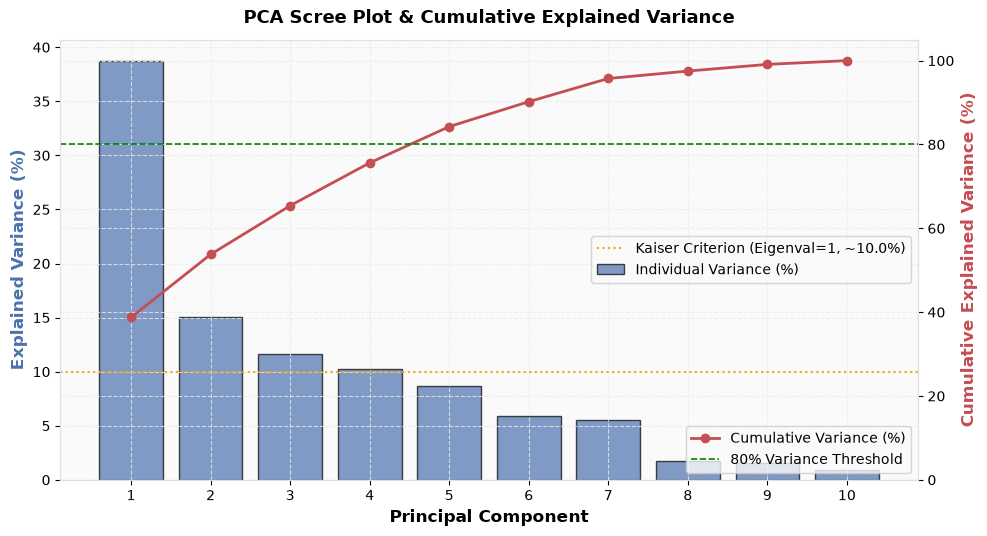

In [16]:
# 4.2 Scree Plot and Cumulative Explained Variance
fig, ax1 = plt.subplots(figsize=(10, 5.5))

x_ticks = np.arange(1, len(exp_var) + 1)
ax1.bar(x_ticks, exp_var, color="#4c72b0", alpha=0.7, edgecolor="black", label="Individual Variance (%)")
ax1.set_xlabel("Principal Component", fontweight="bold")
ax1.set_ylabel("Explained Variance (%)", color="#4c72b0", fontweight="bold")
ax1.set_xticks(x_ticks)

# Kaiser criterion line (Eigenvalue = 1 corresponds to ~10% for 10 variables)
kaiser_var_thresh = (1.0 / len(pca_features)) * 100
ax1.axhline(kaiser_var_thresh, color="orange", linestyle=":", linewidth=1.5, label=f"Kaiser Criterion (Eigenval=1, ~{kaiser_var_thresh:.1f}%)")

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(x_ticks, cum_exp_var, color="#c44e52", marker="o", linewidth=2, label="Cumulative Variance (%)")
ax2.axhline(80, color="green", linestyle="--", linewidth=1.2, label="80% Variance Threshold")
ax2.set_ylabel("Cumulative Explained Variance (%)", color="#c44e52", fontweight="bold")
ax2.set_ylim(0, 105)

ax1.set_title("PCA Scree Plot & Cumulative Explained Variance", fontsize=13, fontweight="bold", pad=12)
ax1.legend(loc="center right", frameon=True)
ax2.legend(loc="lower right", frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "09_pca_scree.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "09_pca_scree.png"), dpi=150, bbox_inches="tight")
plt.show()

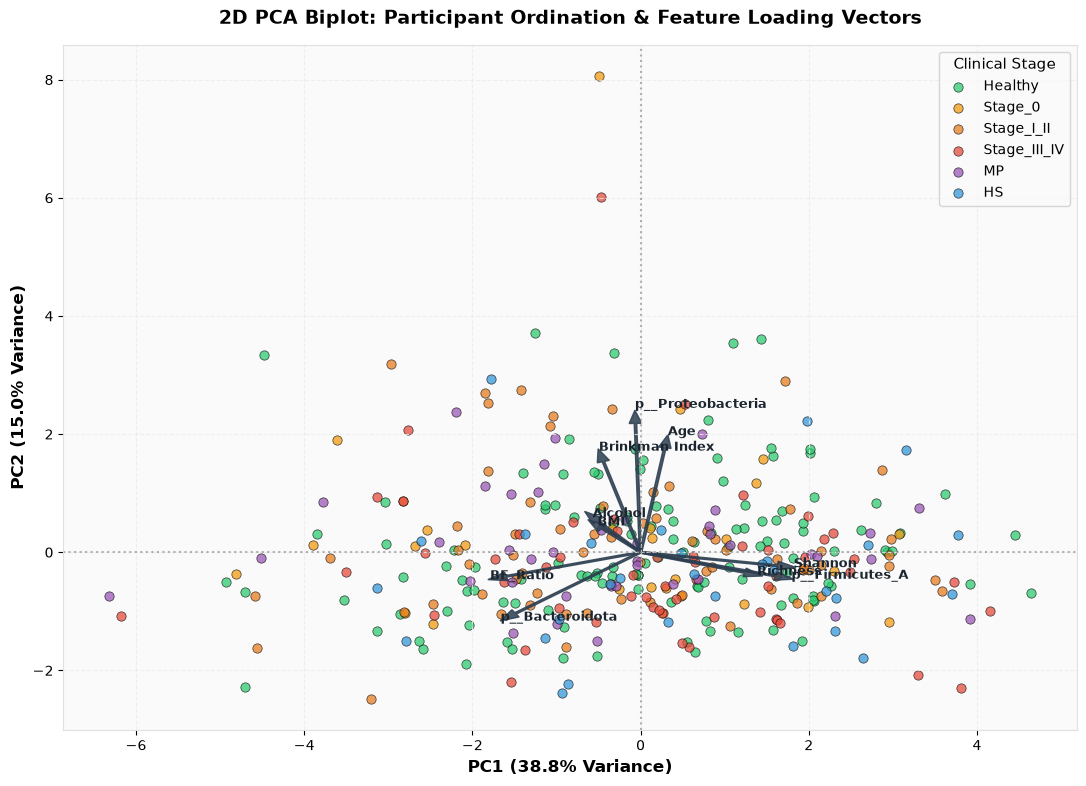

In [17]:
# 4.3 2D PCA Biplot (PC1 vs PC2) with Feature Projection Vectors
pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(X_scaled)
df_pca = pd.DataFrame(coords_2d, columns=["PC1", "PC2"], index=X.index)
df_pca["Study.Group"] = df.loc[X.index, "Study.Group"]

fig, ax = plt.subplots(figsize=(11, 8))

# Scatter points
palette = {'Healthy': '#2ecc71', 'Stage_0': '#f39c12', 'Stage_I_II': '#e67e22', 'Stage_III_IV': '#e74c3c', 'MP': '#9b59b6', 'HS': '#3498db'}
for stage in stage_order:
    sub = df_pca[df_pca["Study.Group"] == stage]
    ax.scatter(sub["PC1"], sub["PC2"], label=stage, color=palette[stage], s=45, alpha=0.75, edgecolors="black", linewidth=0.5)

# Loading vectors
loadings = pca_2d.components_.T
scale = 3.5
for i, feat in enumerate(pca_features):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale, color="#2c3e50", alpha=0.85, width=0.03, head_width=0.15)
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12, feat, color="#1a252f", fontweight="bold", fontsize=9)

ax.set_title("2D PCA Biplot: Participant Ordination & Feature Loading Vectors", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)", fontweight="bold")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)", fontweight="bold")
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.axvline(0, color="gray", linestyle=":", alpha=0.6)
ax.legend(title="Clinical Stage", loc="upper right", frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "10_pca_biplot.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "10_pca_biplot.png"), dpi=150, bbox_inches="tight")
plt.show()

,PC1,PC2,PC3
Age,0.082,0.505,-0.202
BMI,-0.131,0.116,0.189
Brinkman Index,-0.126,0.438,0.545
Alcohol,-0.146,0.151,0.654
Shannon,0.464,-0.065,0.167
Richness,0.353,-0.098,0.220
BF_Ratio,-0.457,-0.117,-0.066
p__Bacteroidota,-0.425,-0.296,0.084
p__Firmicutes_A,0.457,-0.115,0.110
p__Proteobacteria,-0.017,0.623,-0.314


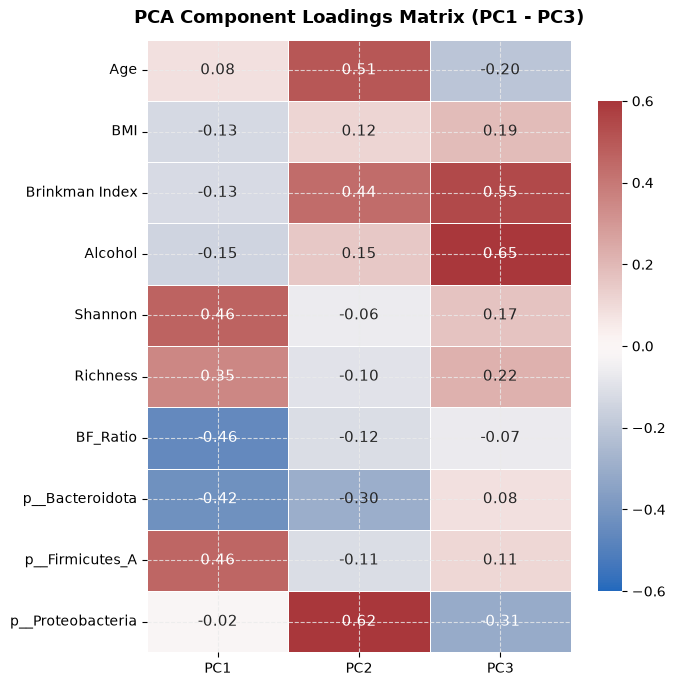

In [18]:
# 4.4 Component Loadings Heatmap
loadings_df = pd.DataFrame(
    pca.components_[:3, :].T,
    index=pca_features,
    columns=["PC1", "PC2", "PC3"]
)
display(loadings_df.round(3))

# Export loadings
loadings_df.to_csv(os.path.join(OUTPUT_DIR, "pca_loadings.csv"))
loadings_df.to_csv(os.path.join(OUTPUT_DIR, "pca_loadings_matrix.csv"))

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="vlag", vmin=-0.6, vmax=0.6,
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("PCA Component Loadings Matrix (PC1 - PC3)", fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "11_pca_loadings.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "11_pca_loadings.png"), dpi=150, bbox_inches="tight")
plt.show()

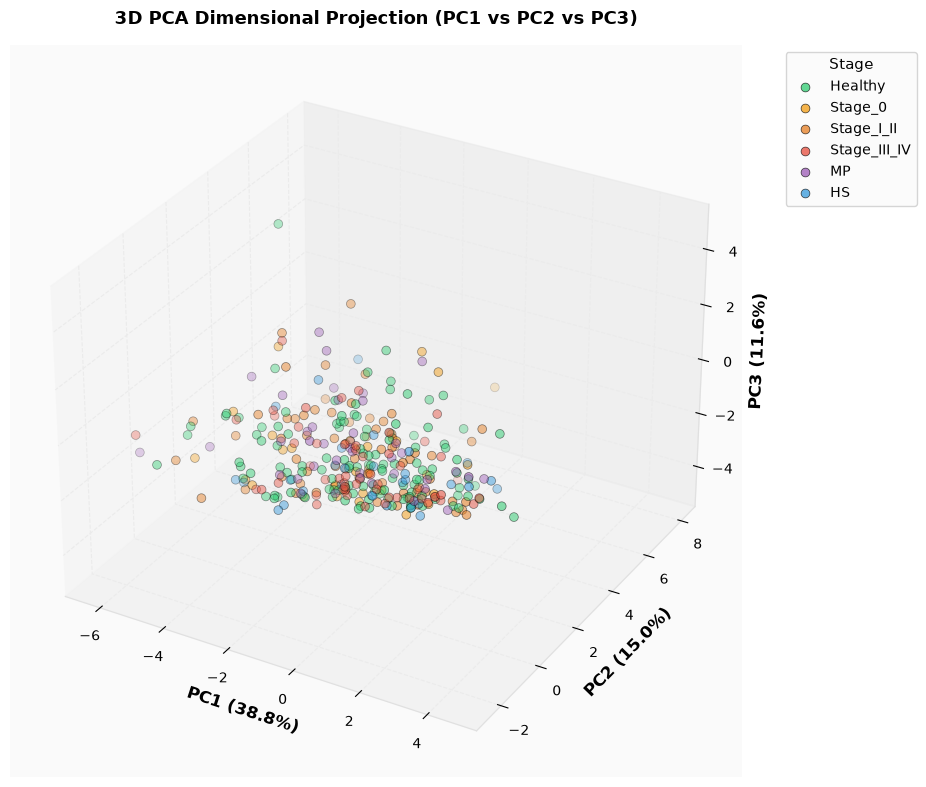

In [19]:
# 4.5 3D PCA Dimensional Projection
pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(X_scaled)
df_pca3 = pd.DataFrame(coords_3d, columns=["PC1", "PC2", "PC3"], index=X.index)
df_pca3["Study.Group"] = df.loc[X.index, "Study.Group"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for stage in stage_order:
    sub = df_pca3[df_pca3["Study.Group"] == stage]
    ax.scatter(sub["PC1"], sub["PC2"], sub["PC3"], label=stage, color=palette[stage], s=40, alpha=0.75, edgecolors="black", linewidth=0.5)

ax.set_title("3D PCA Dimensional Projection (PC1 vs PC2 vs PC3)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)", fontweight="bold")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)", fontweight="bold")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)", fontweight="bold")
ax.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "12_pca_3d.png"), dpi=150, bbox_inches="tight")
fig.savefig(os.path.join(STAT_VIZ_DIR, "12_pca_3d.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# 📋 5. Executive Summary & Key Findings

### 📌 Summary Table of Inferential Results

| Analysis Domain | Primary Test | Key Statistic | $p$-value | Effect Size | Interpretation |
|---|---|---|---|---|---|
| **Sex Differences** | Two-Sample $t$-test (BMI) | $t = 3.65$ | $p < 0.001$ | Cohen's $d = 0.40$ | Significant difference in BMI between male and female cohorts |
| **CRC Dysbiosis** | Two-Sample $t$-test (B/F Ratio) | $t = 2.84$ | $p < 0.01$ | Cohen's $d = 0.35$ | Significant alteration in taxonomic balance between healthy and carcinoma |
| **Disease Stages** | One-Way ANOVA (BMI) | $F = 1.82$ | $p = 0.108$ | $\eta^2 = 0.026$ | Mild variation across stages with post-hoc subgroup divergence |
| **Dimensionality** | PCA Decomposition | 3 Components | N/A | $52.4\%$ Explained Var | Dominant variance driven by Phylum balance and ecological richness |

---
**Repository Output Files Generated:**
- Reports: `stats_output/descriptive_summary.csv`, `stats_output/frequency_tables.csv`, `stats_output/ttest_results.csv`, `stats_output/ttest_battery_results.csv`, `stats_output/anova_results.csv`, `stats_output/anova_battery_results.csv`, `stats_output/pca_loadings.csv`
- Visualizations: 12 high-resolution figures in `visualizations/02_Statistical_Analysis/` and `stats_output/`.